# Análisis de Productos Cosméticos

Este notebook realiza el análisis exploratorio, limpieza y transformación del dataset de productos cosméticos obtenido de Kaggle.

**Diccionario de Variables Clave:**

* `brand`: Marca del cosmético.
* `product_type`: Tipo de producto.
* `price_site`: Precio.
* `view_count`: Numero de visualizaciones (Popularidad).
* `dupes`: ¿Tiene duplicados o similares?
* `shade_img`: Imagen del cosmético.
* `name`: Nombre del producto.
* `rating`: **Variable Objetivo.** Calidad del producto percibida segun los usuarios.


## Contenido
1. Carga de datos
2. Análisis exploratorio inicial
3. Limpieza y transformación de datos
4. Visualizaciones
5. Validación y conclusiones

In [ ]:
# Se importan las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Se ignoran las advertencias (No aparecen mensajes molestos y se ve más limpio)
warnings.filterwarnings('ignore')

# Se configuran las visualizaciones para que se vea profesionalmente
sns.set_theme(style="whitegrid") # Fondo blanco con cuadricula
plt.rcParams['figure.figsize'] = (10, 6) # Define el tamaño de los gráficos

# Se carga el dataset
data_path = '../data/products.csv'
df = pd.read_csv(data_path)

# Información básica del dataset
print("Forma del dataset:", df.shape)
print("\nColumnas:", df.columns.tolist())
print("\nTipos de datos:")
print(df.dtypes)

# Mostrar primeras filas
df.head()

,ID,brand,name,product_type,img,rating,dupes,description,shade_img,price_site,view_count
0,1,Butter London,Handbag Holiday Cutile Oil,\nTreatment\n,NaN,NaN,NaN,"With added vitamins A and E, this heavenly-sme...",NaN,NaN,0
1,2,Butter London,LIPPY,\nLipgloss\n,NaN,NaN,NaN,Lippy: British slang for someone who makes imp...,"[{""shade"":""Come to Bed Red"",""img"":""https://www...",NaN,0
2,3,Butter London,Hardwear P.D. Quick Top Coat,\nTop Coat\n,NaN,NaN,NaN,"Lock your lacquer. butter LONDON's quick-dry, ...",NaN,NaN,0
3,4,Butter London,Horse Power Nail Fertilizer,\nTreatment\n,NaN,NaN,NaN,Reap what you sow. butter LONDON's Nail Fertil...,NaN,NaN,0
4,5,Butter London,Kitten Heels Powder Finish Foot Creme,\nCream\n,NaN,NaN,NaN,"Kitten Heels, our miraculous Powder Finish Foo...",NaN,NaN,0


# 1. Búsqueda de valores inconsistentes

En algunos datasets, los valores faltantes no siempre aparecen como `NaN`, sino que pueden estar representados como texto (por ejemplo, "unknown", "N/A" o valores vacíos).

En este caso, se realiza una exploración de las variables categóricas para identificar posibles valores inconsistentes, caracteres extraños o formatos incorrectos que puedan afectar el análisis.

In [ ]:
# Se imprime el titulo
print("Valores sospechosos tipo texto")

# Se recorren todas las columnas del dataset
for col in df.columns: # Se devuelve una lista con los nombres
    if df[col].dtype == 'object': # Solo analiza las columnas que sean de tipo string
        print(f"\nColumna: {col}") # Se imrpime en nombre de la columna
        print(df[col].unique()[:10]) # Se obtienen los valores unicos de cada columna

Mediante la exploración de valores únicos en las variables categóricas, se identificaron diversos problemas en la calidad de los datos:

- La columna product_type presenta caracteres de salto de línea (\n), lo que indica un formato inconsistente.
- Las columnas shade_img y price_site contienen estructuras tipo JSON almacenadas como texto, lo que dificulta su análisis directo.
- La columna img contiene URLs y valores nulos, por lo que no es relevante para el análisis.
- La columna description contiene texto largo que no será utilizado en el análisis exploratorio.

In [ ]:
# Se imprime el titulo
print("Conteo de valores nulos")

# Se imprime la tabla
print(df.isnull().sum().sort_values(ascending=False))
# Se convierte en una tabla de True/False y se ordenan de mayor a menor

Se observa que varias columnas presentan una gran cantidad de datos faltantes, especialmente:

- dupes y rating, que tienen más de 10.000 valores nulos, lo que indica que estas variables podrían no ser útiles para el análisis si no se imputan o eliminan.
- price_site e img también presentan un alto nivel de ausencia de datos.
- shade_img tiene una cantidad moderada de valores faltantes.
- product_type tiene muy pocos valores nulos, por lo que no representa un problema significativo.

# 2. Limpieza de Datos

Luego de identificar problemas en el dataset, se procede a realizar la limpieza de los datos para mejorar su calidad y facilitar el análisis posterior.

**Eliminación de columnas irrelevantes o con muchos valores nulos**
* `dupes`
* `rating`
* `price_site`
* `img`

Estas variables presentan más del 70% de datos nulos, por lo que se decide eliminarlas, ya que no aportan información confiable para el análisis.

In [ ]:
df = df.drop(columns=['dupes', 'rating', 'price_site', 'img'])

**Limpieza de texto en variables categóricas**
Se detectó que la variable product_type contiene caracteres innecesarios como saltos de línea (\n), lo que puede afectar el análisis.

In [ ]:
df['product_type'] = df['product_type'].str.strip()

In [ ]:
# Estadísticas descriptivas
print("Estadísticas descriptivas para columnas numéricas:")
print(df.describe())

print("\nEstadísticas para view_count:")
print(df['view_count'].describe())

print("\nValores únicos en product_type:")
print(df['product_type'].value_counts())

print("\nTop 10 marcas:")
print(df['brand'].value_counts().head(10))

Estadísticas descriptivas para columnas numéricas:
                 ID  rating  dupes    view_count
count  10667.000000     0.0    0.0  10667.000000
mean    5483.929690     NaN    NaN      0.001125
std     3146.658454     NaN    NaN      0.116188
min        1.000000     NaN    NaN      0.000000
25%     2782.500000     NaN    NaN      0.000000
50%     5498.000000     NaN    NaN      0.000000
75%     8212.500000     NaN    NaN      0.000000
max    10895.000000     NaN    NaN     12.000000

Estadísticas para view_count:
count    10667.000000
mean         0.001125
std          0.116188
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         12.000000
Name: view_count, dtype: float64

Valores únicos en product_type:
product_type
\nPowder\n         1005
\nFace\n            960
\nLiquid\n          939
\nEye\n             810
\nCream\n           718
                   ... 
\nDry Shampoo\n       1
\nDefining\n          1
\nHair\n              1
\nSkin

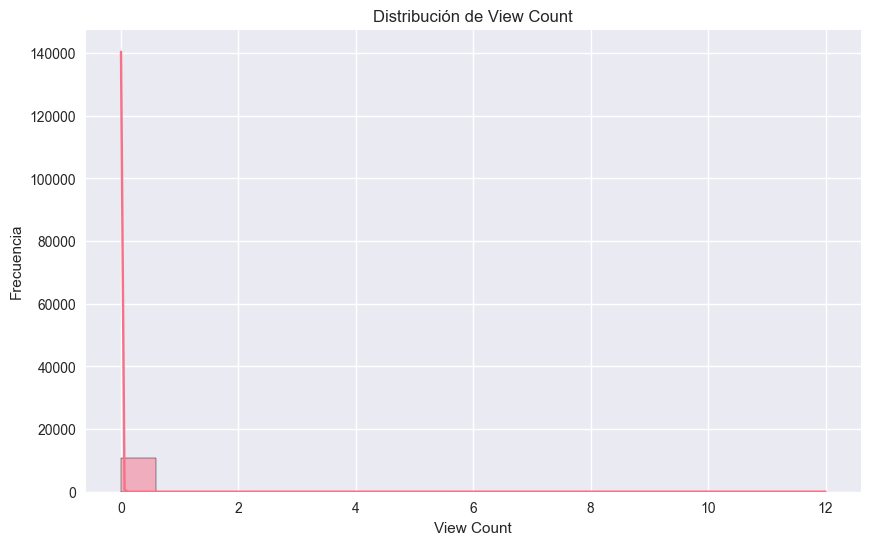

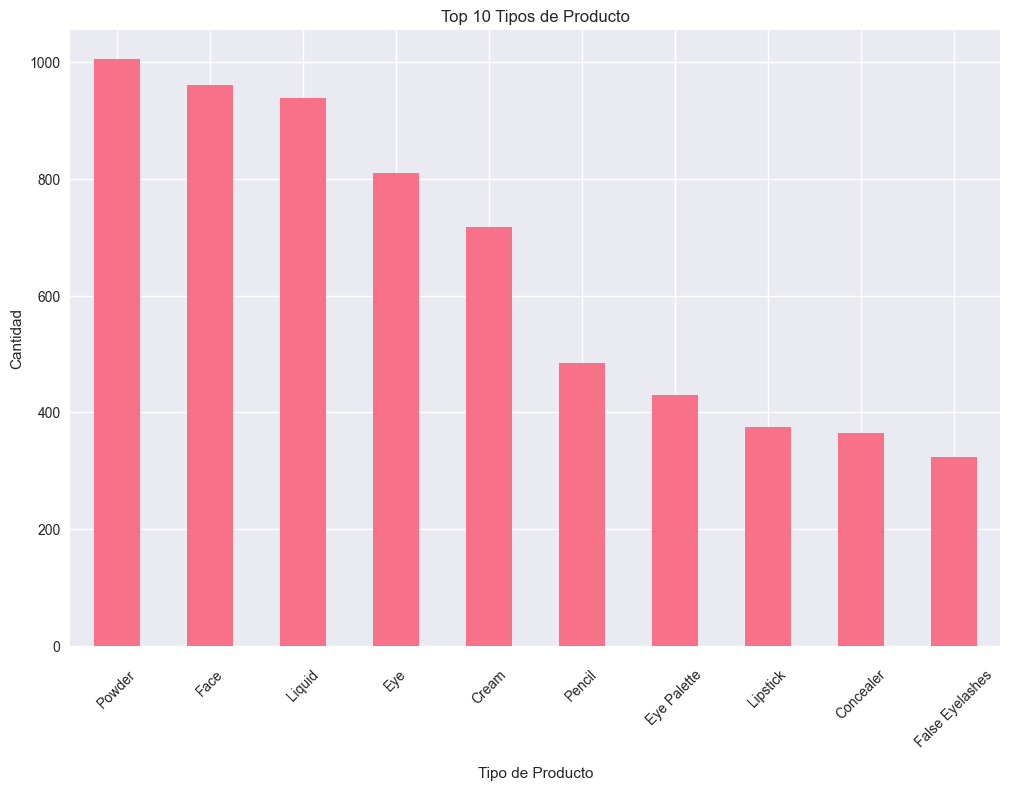

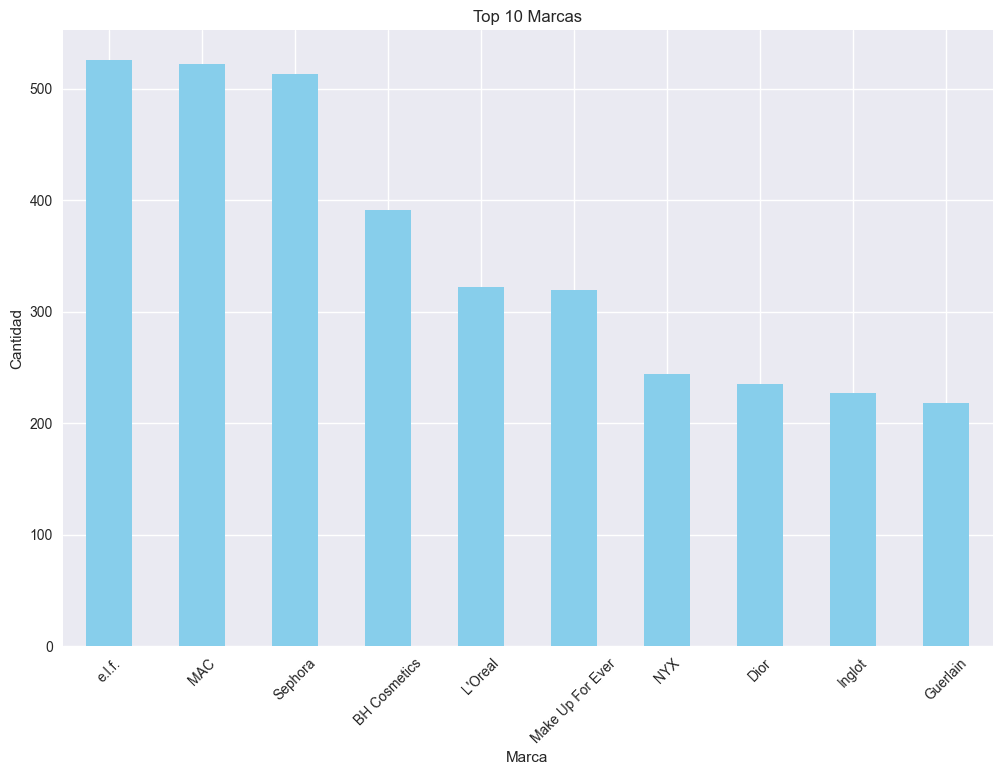

In [4]:
# Visualizaciones
# Distribución de view_count
plt.figure(figsize=(10,6))
sns.histplot(df['view_count'], bins=20, kde=True)
plt.title('Distribución de View Count')
plt.xlabel('View Count')
plt.ylabel('Frecuencia')
plt.show()

# Top 10 tipos de producto
top_types = df['product_type'].value_counts().head(10)
plt.figure(figsize=(12,8))
top_types.plot(kind='bar')
plt.title('Top 10 Tipos de Producto')
plt.xlabel('Tipo de Producto')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

# Top 10 marcas
top_brands = df['brand'].value_counts().head(10)
plt.figure(figsize=(12,8))
top_brands.plot(kind='bar', color='skyblue')
plt.title('Top 10 Marcas')
plt.xlabel('Marca')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

In [6]:
# Limpieza y transformación de datos
# Crear una copia del dataframe
df_clean = df.copy()

# Limpiar product_type: remover \n y espacios, manejar nulos
df_clean['product_type'] = df_clean['product_type'].fillna('Unknown').str.replace('\n', '').str.strip()

# Agregar columna para longitud de descripción
df_clean['description_length'] = df_clean['description'].str.len()

# Agregar columna para si tiene imagen
df_clean['has_image'] = df_clean['img'].notna()

# Agregar columna para si tiene shade image
df_clean['has_shade_image'] = df_clean['shade_img'].notna()

# Eliminar columnas con muchos nulos o no útiles: rating, dupes, price_site
df_clean.drop(columns=['rating', 'dupes', 'price_site'], inplace=True)

# Verificar el resultado
print("Forma del dataset limpio:", df_clean.shape)
print("\nColumnas limpias:", df_clean.columns.tolist())
print("\nValores nulos después de limpieza:")
print(df_clean.isnull().sum())

Forma del dataset limpio: (10667, 11)

Columnas limpias: ['ID', 'brand', 'name', 'product_type', 'img', 'description', 'shade_img', 'view_count', 'description_length', 'has_image', 'has_shade_image']

Valores nulos después de limpieza:
ID                       0
brand                    0
name                     0
product_type             0
img                   9473
description              0
shade_img             4120
view_count               0
description_length       0
has_image                0
has_shade_image          0
dtype: int64


In [7]:
# Validación de la integridad de los datos
# Verificar duplicados
duplicates = df_clean.duplicated().sum()
print(f"Número de filas duplicadas: {duplicates}")

# Verificar IDs únicos
unique_ids = df_clean['ID'].nunique()
print(f"IDs únicos: {unique_ids} de {len(df_clean)} filas")

# Estadísticas después de limpieza
print("\nEstadísticas descriptivas del dataset limpio:")
print(df_clean.describe())

# Guardar el dataset limpio
output_path = '../data/products_cleaned.csv'
df_clean.to_csv(output_path, index=False)
print(f"\nDataset limpio guardado en: {output_path}")

Número de filas duplicadas: 0
IDs únicos: 10667 de 10667 filas

Estadísticas descriptivas del dataset limpio:
                 ID    view_count  description_length
count  10667.000000  10667.000000        10667.000000
mean    5483.929690      0.001125          264.471079
std     3146.658454      0.116188          204.592977
min        1.000000      0.000000            5.000000
25%     2782.500000      0.000000          122.000000
50%     5498.000000      0.000000          204.000000
75%     8212.500000      0.000000          355.000000
max    10895.000000     12.000000         3233.000000

Dataset limpio guardado en: ../data/products_cleaned.csv


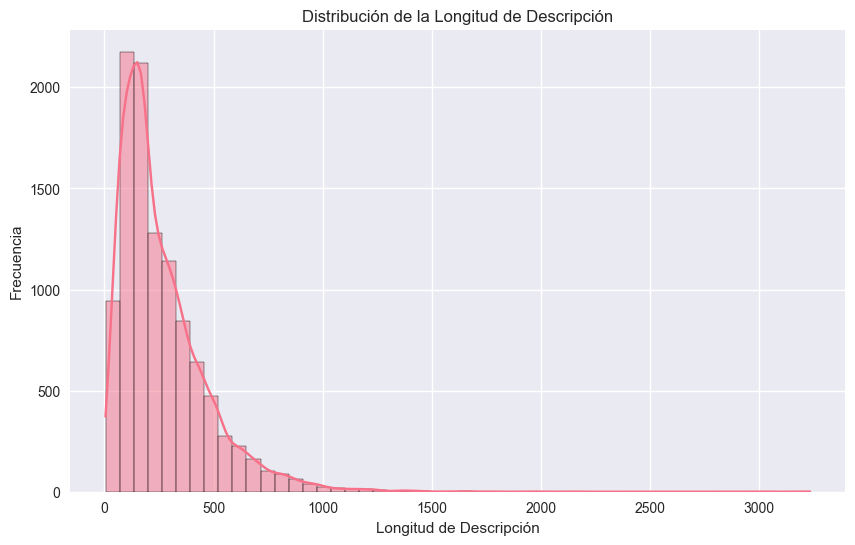

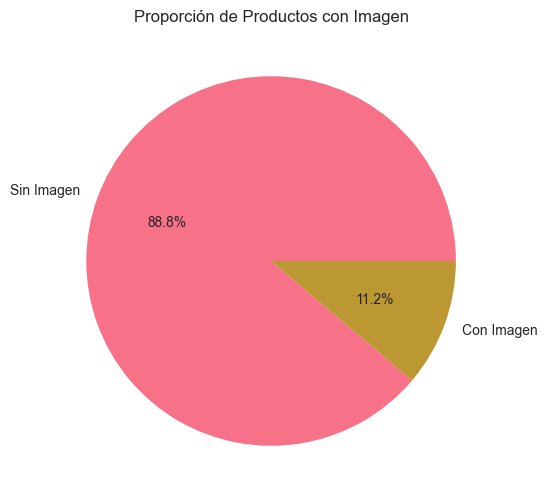

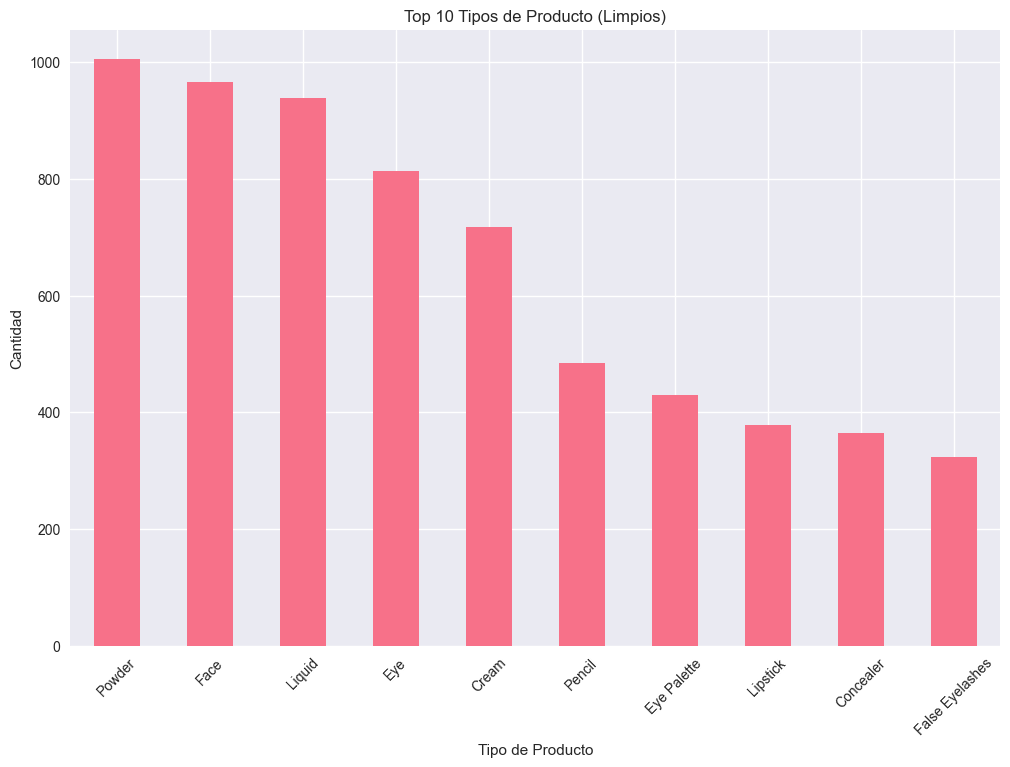

### Conclusiones del Análisis
1. El dataset contiene 10,667 productos cosméticos únicos.
2. Las columnas 'rating', 'dupes' y 'price_site' están mayoritariamente vacías y fueron eliminadas.
3. La mayoría de los productos no tienen imágenes (89% sin img, 39% sin shade_img).
4. Los tipos de producto más comunes son Powder, Face, Liquid, Eye, Cream.
5. Marcas líderes: e.l.f., MAC, Sephora.
6. View_count es bajo en general, indicando poca interacción.
7. Las descripciones varían en longitud, promedio 264 caracteres.


In [8]:
# Análisis adicional y visualizaciones finales
# Distribución de longitud de descripción
plt.figure(figsize=(10,6))
sns.histplot(df_clean['description_length'], bins=50, kde=True)
plt.title('Distribución de la Longitud de Descripción')
plt.xlabel('Longitud de Descripción')
plt.ylabel('Frecuencia')
plt.show()

# Proporción de productos con imagen
image_counts = df_clean['has_image'].value_counts()
plt.figure(figsize=(6,6))
image_counts.plot(kind='pie', autopct='%1.1f%%', labels=['Sin Imagen', 'Con Imagen'])
plt.title('Proporción de Productos con Imagen')
plt.show()

# Top tipos limpios
top_types_clean = df_clean['product_type'].value_counts().head(10)
plt.figure(figsize=(12,8))
top_types_clean.plot(kind='bar')
plt.title('Top 10 Tipos de Producto (Limpios)')
plt.xlabel('Tipo de Producto')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

# Conclusiones
print("### Conclusiones del Análisis")
print("1. El dataset contiene 10,667 productos cosméticos únicos.")
print("2. Las columnas 'rating', 'dupes' y 'price_site' están mayoritariamente vacías y fueron eliminadas.")
print("3. La mayoría de los productos no tienen imágenes (89% sin img, 39% sin shade_img).")
print("4. Los tipos de producto más comunes son Powder, Face, Liquid, Eye, Cream.")
print("5. Marcas líderes: e.l.f., MAC, Sephora.")
print("6. View_count es bajo en general, indicando poca interacción.")
print("7. Las descripciones varían en longitud, promedio 264 caracteres.")